In [1]:
# import sys
# !{sys.executable} -m pip install richdem

In [2]:
import rasterio
import rasterio.mask
import numpy as np
import richdem as rd
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
dem_path = 'data/DEM/RegressionRidge_DEM.tif'

with rasterio.open(dem_path) as src:
    dem = src.read(1)
    dem[dem == src.nodata] = np.nan  # mask no-data
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]


# Basic stats
print('Min elevation:', np.nanmin(dem))
print('Max elevation:', np.nanmax(dem))
print('Mean elevation:', np.nanmean(dem))

# # 1️⃣ Load DEM
# dem_path = 'data/CanoeRidge_DEM_clip.tif'
# with rasterio.open(dem_path) as src:
#     dem = src.read(1)
#     dem = dem.astype(float)
#     dem[dem == src.nodata] = np.nan


Min elevation: 83.88797
Max elevation: 291.0126
Mean elevation: 184.96689


(array([  97434.,  339294.,  779672., 1022793.,  982082.,  602888.,
         508225.,  514857.,  302840.,  327492.]),
 array([ 83.88797, 104.60043, 125.3129 , 146.02536, 166.73782, 187.45029,
        208.16275, 228.87521, 249.58768, 270.30014, 291.0126 ],
       dtype=float32),
 <a list of 10 Patch objects>)

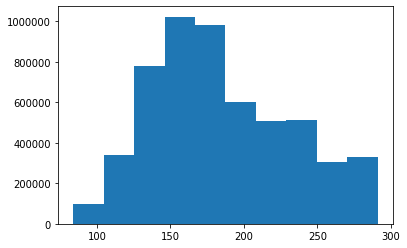

In [4]:
plt.hist(dem[~np.isnan(dem)])

In [32]:
df_features = pd.read_pickle('data/plot_features.pkl')
df_temp = pd.read_pickle('data/PRISM/df.pkl')

In [34]:
df_features

,seasonal_ndvi_mean_of_means,seasonal_ndvi_var_of_means,seasonal_ndvi_mean_of_variance,key_0,plot_id,slope_mean,slope_min,slope_max,aspect_mean,aspect_min,aspect_max,elev_dev_min,elev_dev_max,elev_dev_mean,geometry_x,geometry_y,area_m2,area_ha
0,0.300741,0.000952,0.007581,0,0,7.113986,1.849424,13.003842,168.632449,98.887299,283.569763,17.724625,42.703384,32.015897,"POLYGON ((749515.552 5085017.582, 749593.102 5...","POLYGON ((749515.552 5085017.582, 749593.102 5...",37742.453705,3.774245
1,0.304589,0.001899,0.010456,1,1,7.152989,2.414987,15.321275,169.715627,118.489319,219.622025,-85.736259,-64.172577,-74.677583,"POLYGON ((749293.527 5084266.311, 749284.600 5...","POLYGON ((749293.527 5084266.311, 749284.600 5...",31915.687817,3.191569
2,0.306220,0.002237,0.009142,2,2,11.799543,5.238199,19.049633,163.666617,144.183655,201.497757,-79.243752,-60.861809,-69.693795,"POLYGON ((749683.152 5084433.659, 749663.238 5...","POLYGON ((749683.152 5084433.659, 749663.238 5...",10407.243140,1.040724
3,0.306605,0.003010,0.010650,3,3,9.115794,2.130479,14.148518,165.906402,139.102295,192.083359,-89.877914,-75.192924,-82.771002,"POLYGON ((749671.796 5084356.545, 749653.826 5...","POLYGON ((749671.796 5084356.545, 749653.826 5...",12707.534383,1.270753
4,0.291471,0.001007,0.009137,4,4,6.510597,0.182567,14.545286,155.410061,77.834534,256.087616,-54.026505,-6.260178,-32.046760,"POLYGON ((750026.827 5084777.385, 750031.798 5...","POLYGON ((750026.827 5084777.385, 750031.798 5...",127044.721505,12.704472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,0.311533,0.000848,0.009342,60,60,4.754578,0.006994,13.151122,180.135334,0.939178,359.962067,45.076126,70.332382,58.317643,"POLYGON ((749906.742 5085494.977, 749923.026 5...","POLYGON ((749906.742 5085494.977, 749923.026 5...",94504.390271,9.450439
61,0.329092,0.001611,0.011958,61,61,3.460992,0.020927,13.216408,229.618219,0.158020,359.819122,61.081772,76.793167,69.140051,"POLYGON ((750175.532 5085581.273, 750081.328 5...","POLYGON ((750175.532 5085581.273, 750081.328 5...",46240.992006,4.624099
62,0.309449,0.000937,0.008358,62,62,3.958596,0.018511,8.784628,209.708032,0.000000,359.907288,45.864441,68.142548,58.822801,"POLYGON ((749819.022 5085646.705, 749476.313 5...","POLYGON ((749819.022 5085646.705, 749476.313 5...",96198.910650,9.619891
63,0.313362,0.000838,0.010352,63,63,3.333601,0.015392,9.888171,185.447198,0.347412,359.906097,33.955109,56.417480,46.717775,"POLYGON ((749602.788 5085360.138, 749606.595 5...","POLYGON ((749602.788 5085360.138, 749606.595 5...",97439.734996,9.743973


In [35]:
df_static = df_features
weather = pd.read_pickle('data/PRISM/df.pkl')



weather = (
    weather
    .groupby("date", as_index=False)
    .first()
)


weather['date'] = pd.to_datetime(weather['date'])
weather['doy'] = weather['date'].dt.dayofyear
weather['year'] = weather['date'].dt.year

weather = weather[(weather['doy'] >= 90) & (weather['doy'] <= 300)]

weather['key'] = 1
df_static['key'] = 1

df_long = df_static.merge(weather, on='key').drop('key', axis=1)
df_long = df_long.reset_index(drop=True)

In [36]:
critical_temp = 0  # frost threshold

df_long['slope_norm'] = (df_long['slope_mean'] - df_long['slope_mean'].min()) / \
                        (df_long['slope_mean'].max() - df_long['slope_mean'].min())


df_long['elev_dev_norm'] = (df_long['elev_dev_mean'] - df_long['elev_dev_mean'].min()) / \
                           (df_long['elev_dev_mean'].max() - df_long['elev_dev_mean'].min())


df_long['ndvi_norm'] = (df_long['seasonal_ndvi_mean_of_means'] - df_long['seasonal_ndvi_mean_of_means'].min()) / \
                       (df_long['seasonal_ndvi_mean_of_means'].max() - df_long['seasonal_ndvi_mean_of_means'].min())

df_long['area_norm'] = (df_long['area_m2'] - df_long['area_m2'].min()) / \
                       (df_long['area_m2'].max() - df_long['area_m2'].min())

# Example: larger plots slightly reduce frost risk
# df_long['frost_risk'] += -0.1 * df_long['area_norm']

temp_deficit = (critical_temp - df_long['tmin']).clip(lower=0)
max_deficit = temp_deficit.max()

temp_norm = temp_deficit / max_deficit


df_long['frost_risk'] = (
    (1 - df_long['slope_norm']) * 0.4 +
    (1 - df_long['elev_dev_norm']) * 0.35 +
    (1 - df_long['ndvi_norm']) * 0.15 +
    (1 - df_long['area_norm']) * 0.1
)



# normalize to 0–1 per season or globally
df_long['frost_risk'] = df_long['frost_risk'] / df_long['frost_risk'].max()


In [37]:
df_plot_summary = df_long.groupby('plot_id')['frost_risk'].agg(
    frost_risk_mean='mean',
    frost_risk_std='std',
    frost_risk_max='max'
).reset_index()


In [39]:
df_map = df_features[['plot_id', 'geometry_x']].merge(df_plot_summary, on='plot_id')


In [40]:
gdf = gpd.GeoDataFrame(df_map, geometry='geometry_x')


In [42]:
vineyard = gpd.read_file("data/polygons/RegressionRidge.geojson")


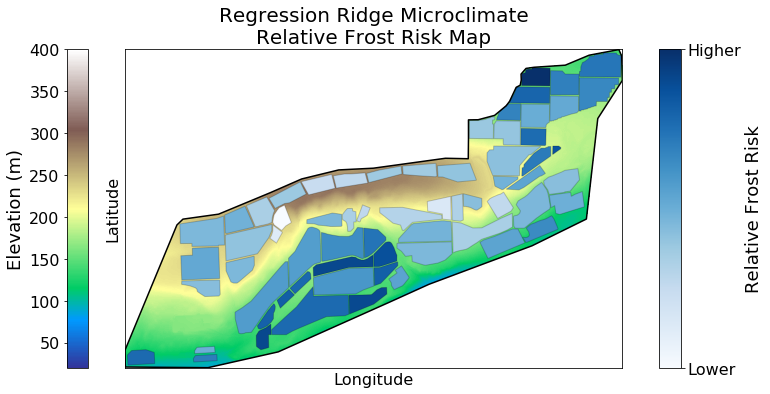

In [49]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import geopandas as gpd

# Ensure GeoDataFrames are in same CRS as DEM
vineyard = vineyard.to_crs(src.crs)
gdf = gdf.to_crs(src.crs)

fig, ax = plt.subplots(figsize=(11, 7))

# 1️⃣ DEM background
im_dem = ax.imshow(
    dem,
    extent=extent,
    origin='upper',
    cmap='terrain',
    vmin = 20,
    vmax = 400
)

# 2️⃣ Overlay frost risk
im_frost = gdf.plot(
    ax=ax,
    column='frost_risk_mean',
    cmap='Blues',
    alpha=1.2,
    edgecolor='black',
    legend=False ,
)

# 3️⃣ Vineyard outline
vineyard.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=1.5
)

# 4️⃣ Axes limits and ticks
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Regression Ridge Microclimate\nRelative Frost Risk Map', fontsize = 20)
ax.set_xlabel('Longitude', fontsize = 16)
ax.set_ylabel('Latitude', fontsize = 16)
# 5️⃣ Create two colorbars
divider = make_axes_locatable(ax)

# Elevation colorbar on the left
cax_left = divider.append_axes("left", size="3%", pad=-1)
cbar_dem = plt.colorbar(im_dem, cax=cax_left)
cbar_dem.set_label('Elevation (m)', fontsize = 18)
cbar_dem.ax.tick_params(labelsize=16)  # set tick label font size

cax_left.yaxis.set_label_position('left')
cax_left.yaxis.set_ticks_position('left')

# Frost risk colorbar on the right
cax_right = divider.append_axes("right", size="3%", pad=-1)
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=gdf['frost_risk_mean'].min(), vmax=gdf['frost_risk_mean'].max())
sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm)
sm.set_array([])
cbar_frost = plt.colorbar(sm, cax=cax_right, cmap = 'Blues')
cbar_frost.set_ticks([gdf['frost_risk_mean'].min(), gdf['frost_risk_mean'].max()])
cbar_frost.set_ticklabels(['Lower', 'Higher'])
cbar_frost.ax.tick_params(labelsize=16)  # set tick label font size

cbar_frost.set_label('Relative Frost Risk', size = 18)
# Set tick positions and labels
plt.savefig('img/frost_risk.png')

plt.show()
